In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_recall_curve, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
# Use tf.keras directly to avoid conflicts with standalone keras
# Assign to variables for easier use
layers = tf.keras.layers
models = tf.keras.models
regularizers = tf.keras.regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
import os
import kagglehub
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

path = kagglehub.dataset_download("shayanfazeli/heartbeat")

train_path = os.path.join(path, 'mitbih_train.csv')
test_path = os.path.join(path, 'mitbih_test.csv')

train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)

print(f"Training set: {train_df.shape}, Test set: {test_df.shape}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training set: (87554, 188), Test set: (21892, 188)
GPU available: False


Training distribution:
  Normal: 72471 (82.8%)
  Supraventricular: 2223 (2.5%)
  Ventricular: 5788 (6.6%)
  Fusion: 641 (0.7%)
  Unknown: 6431 (7.3%)


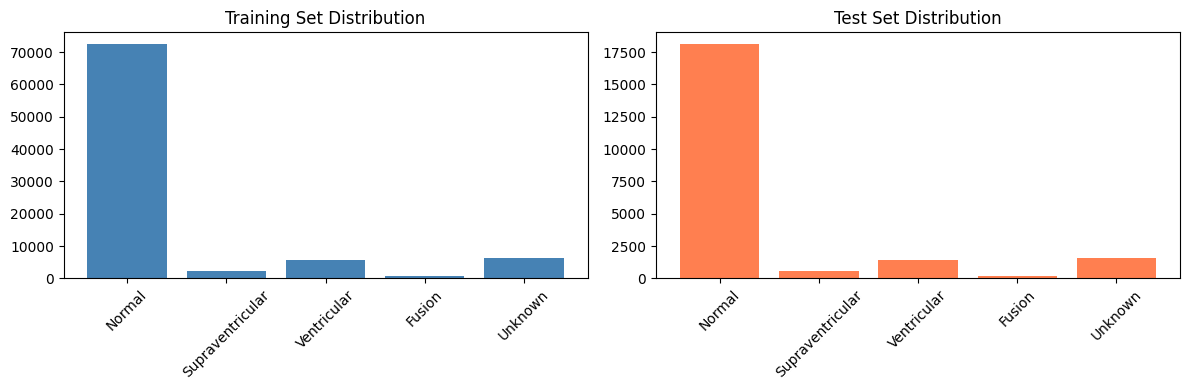

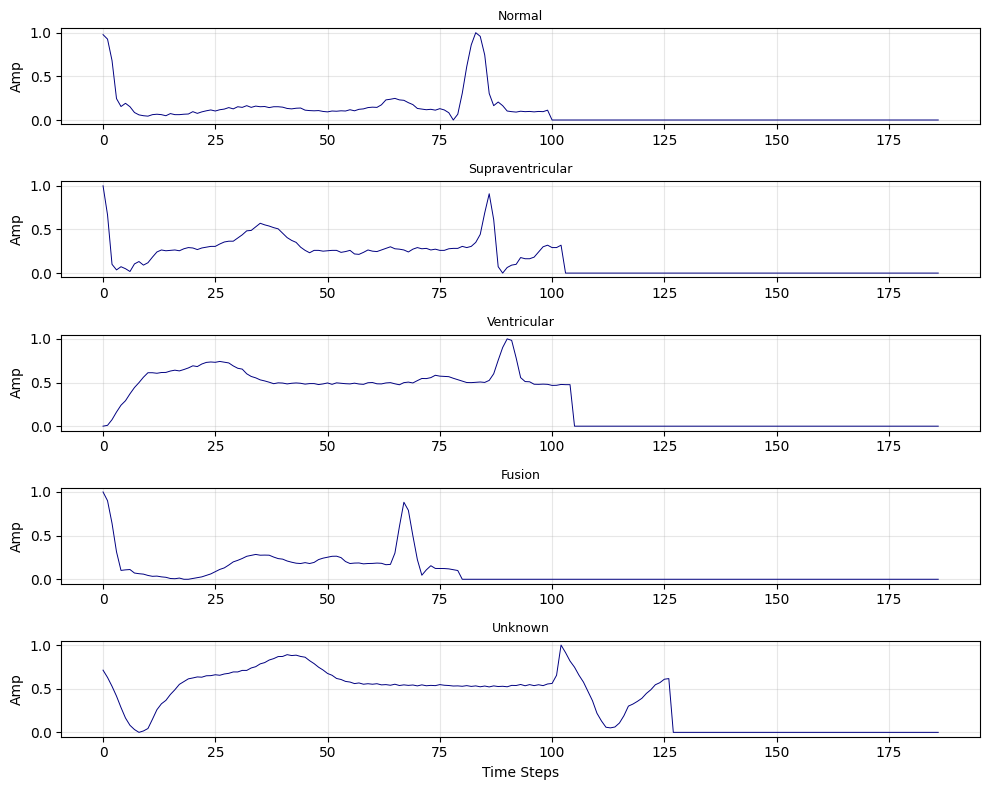

In [2]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

class_names = {0: 'Normal', 1: 'Supraventricular', 2: 'Ventricular', 3: 'Fusion', 4: 'Unknown'}
num_classes = len(class_names)

unique, counts = np.unique(y_train, return_counts=True)
print("Training distribution:")
for cls, count in zip(unique, counts):
    print(f"  {class_names[cls]}: {count} ({count/len(y_train)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([class_names[c] for c in unique], counts, color='steelblue')
axes[0].set_title('Training Set Distribution')
axes[0].tick_params(axis='x', rotation=45)

unique_test, counts_test = np.unique(y_test, return_counts=True)
axes[1].bar([class_names[c] for c in unique_test], counts_test, color='coral')
axes[1].set_title('Test Set Distribution')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 1, figsize=(10, 8))
for i, cls in enumerate(unique):
    sample_idx = np.where(y_train == cls)[0][0]
    axes[i].plot(X_train[sample_idx], linewidth=0.7, color='navy')
    axes[i].set_title(f'{class_names[cls]}', fontsize=9)
    axes[i].set_ylabel('Amp')
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('Time Steps')
plt.tight_layout()
plt.show()

In [3]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

def augment_minority_classes(X, y, target_ratio=0.3):
    """Augment minority classes using noise injection and time shifting"""
    unique_classes, class_counts = np.unique(y, return_counts=True)
    max_count = max(class_counts)
    target_count = int(max_count * target_ratio)
    
    X_aug, y_aug = [X.copy()], [y.copy()]
    
    for cls, count in zip(unique_classes, class_counts):
        if count < target_count:
            cls_indices = np.where(y == cls)[0]
            samples_needed = target_count - count
            
            for _ in range(samples_needed):
                idx = np.random.choice(cls_indices)
                sample = X[idx].copy()
                
                aug_type = np.random.choice(['noise', 'shift', 'scale'])
                if aug_type == 'noise':
                    noise = np.random.normal(0, 0.05, sample.shape)
                    sample = sample + noise
                elif aug_type == 'shift':
                    shift = np.random.randint(-10, 10)
                    sample = np.roll(sample, shift)
                else:
                    scale = np.random.uniform(0.9, 1.1)
                    sample = sample * scale
                
                X_aug.append(sample.reshape(1, -1))
                y_aug.append(np.array([cls]))
    
    return np.vstack(X_aug), np.concatenate(y_aug)

X_train_aug, y_train_aug = augment_minority_classes(X_train_scaled, y_train_split, target_ratio=0.25)

shuffle_idx = np.random.permutation(len(y_train_aug))
X_train_aug = X_train_aug[shuffle_idx]
y_train_aug = y_train_aug[shuffle_idx]

X_train_reshaped = X_train_aug.reshape(X_train_aug.shape[0], X_train_aug.shape[1], 1)
X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train_aug), y=y_train_aug)
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print(f"Original training: {len(y_train_split)}, Augmented: {len(y_train_aug)}")
print(f"Validation: {len(y_val)}, Test: {len(y_test)}")
print(f"Input shape: {X_train_reshaped.shape[1:]}")

Original training: 74420, Augmented: 123200
Validation: 13134, Test: 21892
Input shape: (187, 1)


In [4]:
# Use tf.keras directly to avoid any import conflicts
# Import tensorflow first (should be done in Cell 0)
import tensorflow as tf

# Use tf.keras directly instead of importing
layers = tf.keras.layers
models = tf.keras.models
regularizers = tf.keras.regularizers

class AttentionLayer(layers.Layer):
    """Self-attention mechanism for sequence data"""
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                  shape=(input_shape[-1], input_shape[-1]),
                                  initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                  shape=(input_shape[-1],),
                                  initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)
        
    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = tf.reduce_sum(x * a, axis=1)
        return output


def create_bilstm_attention(input_shape, num_classes):
    """Bidirectional LSTM with Attention - Best for capturing temporal patterns"""
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, 
                                          kernel_regularizer=regularizers.l2(0.001)))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True,
                                          kernel_regularizer=regularizers.l2(0.001)))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = AttentionLayer()(x)
    
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, outputs, name='BiLSTM_Attention')


def create_cnn_lstm(input_shape, num_classes):
    """CNN-LSTM Hybrid - Excellent for feature extraction + temporal modeling"""
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False,
                                          kernel_regularizer=regularizers.l2(0.001)))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, outputs, name='CNN_LSTM')


def create_stacked_bilstm(input_shape, num_classes):
    """Deep Stacked Bidirectional LSTM with residual connections"""
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True,
                                          kernel_regularizer=regularizers.l2(0.001)))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    lstm_out = layers.Bidirectional(layers.LSTM(128, return_sequences=True,
                                                 kernel_regularizer=regularizers.l2(0.001)))(x)
    lstm_out = layers.BatchNormalization()(lstm_out)
    x = layers.Add()([x, lstm_out])
    x = layers.Dropout(0.3)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False,
                                          kernel_regularizer=regularizers.l2(0.001)))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, outputs, name='Stacked_BiLSTM')


input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])

bilstm_attention = create_bilstm_attention(input_shape, num_classes)
cnn_lstm = create_cnn_lstm(input_shape, num_classes)
stacked_bilstm = create_stacked_bilstm(input_shape, num_classes)

print("BiLSTM with Attention:")
print(f"  Parameters: {bilstm_attention.count_params():,}")
print("\nCNN-LSTM Hybrid:")
print(f"  Parameters: {cnn_lstm.count_params():,}")
print("\nStacked BiLSTM:")
print(f"  Parameters: {stacked_bilstm.count_params():,}")



BiLSTM with Attention:
  Parameters: 324,357

CNN-LSTM Hybrid:
  Parameters: 199,941

Stacked BiLSTM:
  Parameters: 719,877


In [11]:
def cosine_decay_with_warmup(epoch, lr, warmup_epochs=5, total_epochs=50):
    if epoch < warmup_epochs:
        return lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return lr * 0.5 * (1 + np.cos(np.pi * progress))

def get_callbacks(model_name, patience=15):
    return [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0),
        ModelCheckpoint(f'{model_name}_best.keras', monitor='val_loss', save_best_only=True, verbose=0),
        LearningRateScheduler(lambda e: cosine_decay_with_warmup(e, 0.001), verbose=0)
    ]

all_models = {
    'BiLSTM_Attention': bilstm_attention,
    'CNN_LSTM': cnn_lstm,
    'Stacked_BiLSTM': stacked_bilstm
}

for name, model in all_models.items():
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print("Models compiled with AdamW optimizer and cosine decay schedule")

NameError: name 'keras' is not defined